# Using Log Log etc -  i want to produce a final plot quantifying scaling
- it should be reusable to make the exact same plot for rootx and identity
- so it should import data from a saved file

- not 100% on what the plot should look like - i think side by side one just log y infid and then one loglog that does the quantification

- need to discuss where it is valid to take the scaling from? because you would not put a qubit in the floquet danger zone

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.signal import find_peaks
from scipy.signal import find_peaks
from scipy.stats import linregress

In [14]:

import os
import sys


# --- PATH modification for TinyTeX (BEGIN) ---
tinytex_bin_path = os.path.expanduser("~/Library/TinyTeX/bin/universal-darwin")
if os.path.exists(tinytex_bin_path):
    if tinytex_bin_path not in os.environ['PATH']:
        os.environ['PATH'] = tinytex_bin_path + os.pathsep + os.environ['PATH']
        print(f"Added {tinytex_bin_path} to PATH for this Python session.")
    else:
        print(f"{tinytex_bin_path} already in PATH for this session.")
else:
    print(f"Warning: TinyTeX bin path not found at {tinytex_bin_path}. LaTeX rendering might fail.")
# --- PATH modification for TinyTeX (END) ---


# --- Matplotlib Configuration for LaTeX Integration ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}""",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 12,
    "axes.titlesize": 10,
})



# --- Figure Dimensions for Your LaTeX Document ---
pt_to_inches = 1.0 / 72.27
latex_textwidth_pts = 469.75502 # Standard for A4 article, 10pt
latex_fig_width_inches =1 * latex_textwidth_pts * pt_to_inches  

# Calculate column width: (textwidth - columnsep) / 2
# Your LaTeX sets \columnsep to 0.75cm. Convert 0.75cm to points.
# column_sep_cm = 0.75
# column_sep_pts = column_sep_cm * (72.27 / 2.54) # 72.27 pts/inch, 2.54 cm/inch

# latex_column_width_pts = (latex_textwidth_pts - column_sep_pts) / 2

# # Set figure width to match the calculated column width
# latex_fig_width_inches = latex_column_width_pts * pt_to_inches


# latex_fig_height_inches = latex_fig_width_inches


Added /Users/archie/Library/TinyTeX/bin/universal-darwin to PATH for this Python session.


In [10]:
steel_blue, plum = "#4682B4", "#B44682"

In [12]:
# Load the DataFrame from the saved CSV file
csv_path = '/Users/archie/documents/year4/project/data/identity_scaling_100_rabis.csv'
df = pd.read_csv(csv_path)

# extract the data into variables
# "detunings_normalized": detunings_normalized,
# "infidelities_combined_ccd": infidelities_combined_ccd,
# "infidelities_combined_rabi": infidelities_combined_rabi

detunings_normalized = df['detunings_normalized'].values
infidelities_combined_ccd = df['infidelities_combined_ccd'].values
infidelities_combined_rabi = df['infidelities_combined_rabi'].values

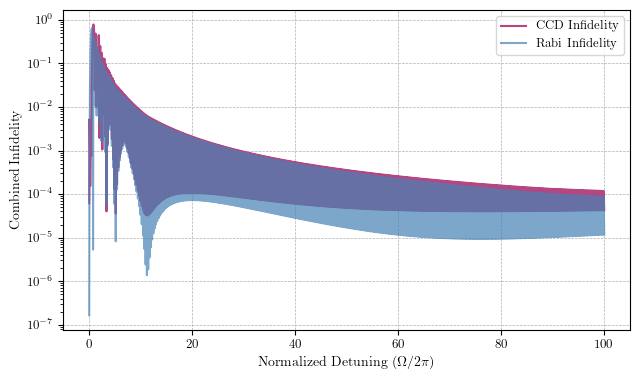

Number of peaks in unlogged CCD infidelity: 397


In [37]:
# Find peaks for unlogged CCD infidelity
ccd_peaks, _ = find_peaks(infidelities_combined_ccd, height=1e-5)  # Adjust height as needed
# Find peaks for unlogged Rabi infidelity
rabi_peaks, _ = find_peaks(infidelities_combined_rabi, height=1e-5)  # Adjust height as needed

# Extract peak values
ccd_peaks_x = detunings_normalized[ccd_peaks]
ccd_peaks_y = infidelities_combined_ccd[ccd_peaks]
rabi_peaks_x = detunings_normalized[rabi_peaks]
rabi_peaks_y = infidelities_combined_rabi[rabi_peaks]

# Plot the original curve and the peaks
plt.figure(figsize=(latex_fig_width_inches,0.6*latex_fig_width_inches))  # Square figure
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="CCD Infidelity", color=plum, alpha=1)
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Rabi Infidelity", color=steel_blue, alpha=0.7)
# plt.scatter(rabi_peaks_x, rabi_peaks_y, color=steel_blue, label="Rabi Peaks", zorder=5, marker='x', s=10)
# plt.scatter(ccd_peaks_x, ccd_peaks_y, color=plum, label="Peaks", zorder=5)
plt.xlabel(r"Normalized Detuning ($\Omega/2\pi$)")
plt.ylabel("Combined Infidelity")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Print the number of peaks
print(f"Number of peaks in unlogged CCD infidelity: {len(ccd_peaks)}")

CCD Fit: y = 6.194e-01 * x^(-1.893), R^2 = 0.998, p-value = 0.00e+00, std_err = 0.004


<>:70: SyntaxWarning: invalid escape sequence '\O'
<>:70: SyntaxWarning: invalid escape sequence '\O'
/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_30528/1043022175.py:70: SyntaxWarning: invalid escape sequence '\O'
  ax.set_xlabel("Normalised Detuning ($\Omega/2\pi$)")


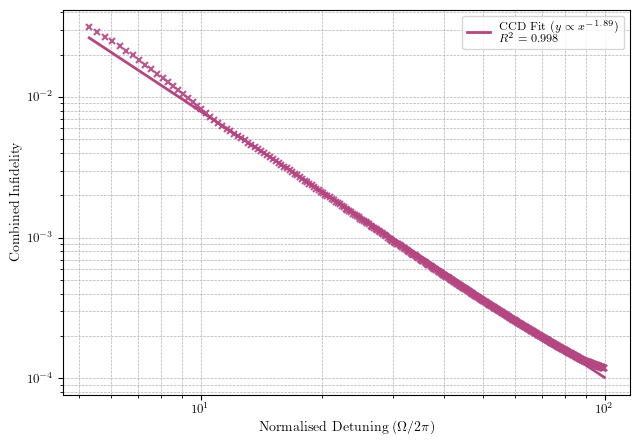


CCD Fit Summary: Slope (k) = -1.893, R^2 = 0.998, A = 6.19e-01
Rabi Fit Summary: Slope (k) = -1.969, R^2 = 1.000, A = 7.09e-01


In [ ]:



def fit_and_plot_peaks_direct(ax, x_full, y_full, color, label_prefix, peak_find_params=None):
    """
    Finds peaks, fits a power law (linear in log-log) to them, plots.
    Direct version assuming suitable data and enough peaks.
    """
    if peak_find_params is None:
        peak_find_params = {} # Default to empty dict if not provided

    # Find peaks
    peak_indices, _ = find_peaks(np.squeeze(y_full), **peak_find_params)

    peaks_x = x_full[peak_indices]
    peaks_y = y_full[peak_indices]

    # Log transform peak data (assumes peaks_x and peaks_y are > 0)
    log_peaks_x = np.log(peaks_x)
    log_peaks_y = np.log(peaks_y)

    # Perform linear regression: log(y) = slope * log(x) + intercept
    # This will fail if len(log_peaks_x) < 2
    slope, intercept, r_value, p_value, std_err = linregress(log_peaks_x, log_peaks_y)
    r_squared = r_value**2

    # Calculate power law parameters: y = A * x^k
    A = np.exp(intercept)
    k = slope
    
    # Generate points for the fitted line using the range of detected peaks
    # Ensure x_line doesn't try to take min/max of an empty array if no peaks were found
    # (though linregress would have failed before this if peak_indices was too short)
    x_line = np.array([peaks_x.min(), peaks_x.max()])
    y_line = A * (x_line**k)

    # Plotting
    # ax.loglog(x_full, y_full, label=f"{label_prefix} Data", color=color, alpha=0.3, linestyle=':')
    ax.loglog(peaks_x, peaks_y, 'x', mfc='none', mec=color, mew=1.5, markersize=5, alpha=0.9, )#label=f"{label_prefix} Peaks")
    ax.loglog(x_line, y_line, color=color, linestyle='-', linewidth=2,
              label=f"{label_prefix} Fit ($y \\propto x^{{{k:.2f}}}$)\n$R^2={r_squared:.3f}$")
    
    fit_results = {'A': A, 'k': k, 'R2': r_squared, 'p_value': p_value, 'std_err': std_err}
    print(f"{label_prefix} Fit: y = {A:.3e} * x^({k:.3f}), R^2 = {r_squared:.3f}, p-value = {p_value:.2e}, std_err = {std_err:.3f}")
    return fit_results

# --- Plotting ---
fig, ax = plt.subplots(figsize=(latex_fig_width_inches, 0.7 * latex_fig_width_inches))

# --- USER: CRITICAL - Tune these peak_find_params for your specific data! ---
# These are just placeholders. Incorrect parameters will lead to poor fits or errors.
# Example: {'prominence': desired_prominence, 'distance': min_peak_separation, 'height': min_peak_height}
peak_params_ccd_tuned = {'height': 1e-6} # YOU MUST ADJUST THIS
peak_params_rabi_tuned = {'height': 1e-6} # YOU MUST ADJUST THIS


# Filter out detunings greater than 1 (normalized)
mask = detunings_normalized > 5

# Filtered arrays
detunings_gt1 = detunings_normalized[mask]
infidelities_ccd_gt1 = infidelities_combined_ccd[mask]
infidelities_rabi_gt1 = infidelities_combined_rabi[mask]


# Call the fitting and plotting function for CCD data
results_ccd = fit_and_plot_peaks_direct(ax, detunings_gt1, infidelities_ccd_gt1, plum, "CCD", peak_find_params=peak_params_ccd_tuned)

# Call the fitting and plotting function for Rabi data
results_rabi = fit_and_plot_peaks_direct(ax, detunings_gt1, infidelities_rabi_gt1, steel_blue, "Rabi", peak_find_params=peak_params_rabi_tuned)

# Setup plot labels, title, grid, and legend
ax.set_xlabel("Normalised Detuning ($\Omega/2\pi$)")
ax.set_ylabel("Combined Infidelity")
# ax.set_title("Infidelity vs. Detuning with Power Law Fit to Peaks")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize='small', loc='best')
plt.tight_layout()

# --- USER: Uncomment and ensure path is correct to save the figure ---
# plt.savefig('/Users/archie/documents/year4/project/Figures_Final/identity_cross_talk_loglog_peak_fit_direct.pdf', dpi=600)
plt.show()

# Optionally, print summary of fit parameters again
if results_ccd: # Check if fit was successful (returned results)
    print(f"\nCCD Fit Summary: Slope (k) = {results_ccd['k']:.3f}, R^2 = {results_ccd['R2']:.3f}, A = {results_ccd['A']:.2e}")
if results_rabi: # Check if fit was successful
    print(f"Rabi Fit Summary: Slope (k) = {results_rabi['k']:.3f}, R^2 = {results_rabi['R2']:.3f}, A = {results_rabi['A']:.2e}")
